In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Read EV Load data

df = pd.read_csv("load_profile_day1.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

df = df.rename(columns={'load_kw': 'ev_load_kw'})

df['hour'] = df['timestamp'].dt.hour + df['timestamp'].dt.minute / 60.0

# Create some dummy base load data

base_min = 20   # minimum base load (kW)
base_max = 60   # peak base load (kW)

morning_peak = np.exp(-0.5 * ((df['hour'] - 8) / 2)**2)
evening_peak = np.exp(-0.5 * ((df['hour'] - 19) / 3)**2)

base_load = base_min + 15 * morning_peak + 30 * evening_peak

# Add some noise
noise = np.random.normal(0, 2, size=len(df))

df['base_load_kw'] = base_load + noise

df['total_load_kw'] = df['ev_load_kw'] + df['base_load_kw']

df['base_load_kw'] = df['base_load_kw'].clip(lower=0)

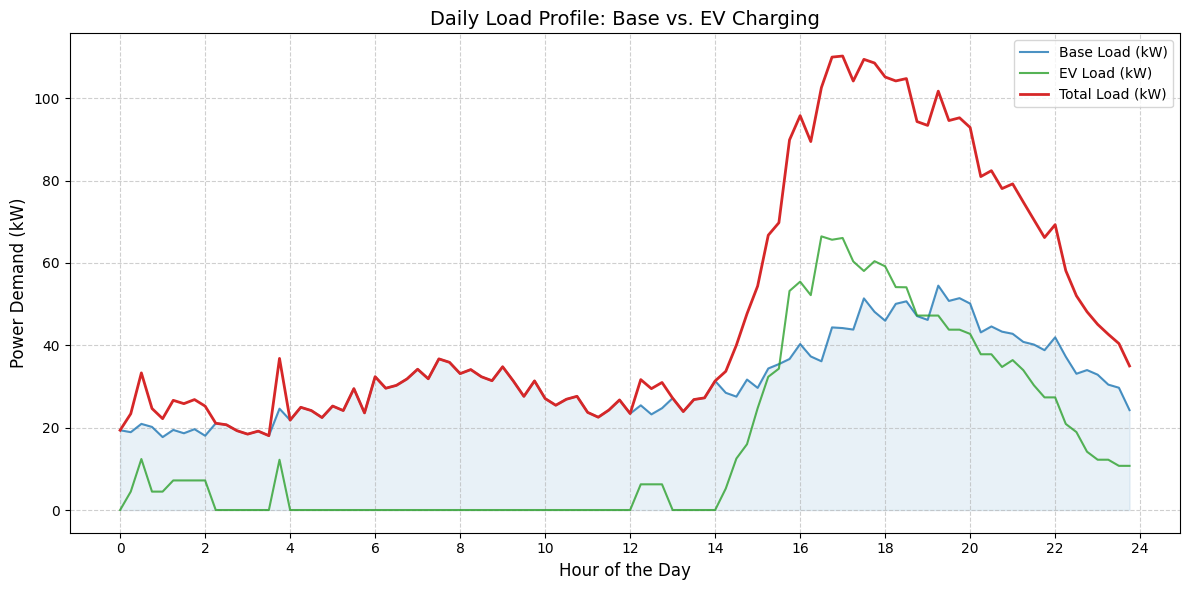

In [10]:
plt.figure(figsize=(12, 6))

# Plot the three different load components
plt.plot(df['hour'], df['base_load_kw'], label='Base Load (kW)', color='tab:blue', alpha=0.8)
plt.plot(df['hour'], df['ev_load_kw'], label='EV Load (kW)', color='tab:green', alpha=0.8)
plt.plot(df['hour'], df['total_load_kw'], label='Total Load (kW)', color='tab:red', linewidth=2)

# Formatting the chart
plt.title('Daily Load Profile: Base vs. EV Charging', fontsize=14)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Power Demand (kW)', fontsize=12)
plt.xticks(range(0, 25, 2))  # Set ticks every 2 hours
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Optional: Add a fill to highlight the gap
plt.fill_between(df['hour'], df['base_load_kw'], color='tab:blue', alpha=0.1)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate how much the transformer is being loaded across time

rated_kw = 100 
df['loading_ratio'] = df['total_load_kw'] / rated_kw